# Evaluation Assurance
### Which of an AI evaluator's PASS verdicts should a human re-check?

Arnav. Everything here runs on synthetic data where I know the ground truth. None of it is Deccan data.

---

An automated evaluator (LLM judge, rubric scorer, verifier) sometimes marks a run as PASS when it actually failed. I'll call these silent failures. Nobody can re-check every PASS, so the question I wanted to answer is: if a human can only re-check some of them, which ones should they look at?

| Review 20% of PASS verdicts using… | Silent failures caught |
|---|---|
| Random spot-check | 20% |
| A model trained on the evaluator's *own* information | 28% |
| A hand-written rule: "count how many execution checks fired" | 45% |
| **Independent execution signals + logistic regression** | **48%**, and **92% precision** at a 5% budget |

What I took away from it:
1. The gain comes from using evidence the evaluator didn't look at. A model that re-reads the evaluator's own inputs barely beats random.
2. A plain rule gets most of the way there. The model only really pulls ahead when the review budget is small: at 5%, 92% of what it flags is a real failure, vs 66% for the rule.
3. Logistic regression was enough. ~260 labels, decently calibrated, and the weights tell the reviewer why something got flagged.

Runs top to bottom in ~2 min. Section 14 has the two versions that didn't work.

## 1 · The problem

```
agent run ──> evaluator ──> PASS ──> ??? which ones does a human re-check ???
```

A PASS from an LLM judge is based mostly on what the agent *said* and *output*. Silent failures hide where the judge doesn't look:

| Mode | What actually went wrong | Independent check that could reveal it |
|---|---|---|
| **A** Edge-case regression | a rare code path broke | coverage reading + rare-path flag |
| **B** State inconsistency | agent said "saved"; the database disagrees | state reconciliation (DB read-back) |
| **C** Wrong tool argument | tool call "succeeded" on the wrong object | sampled tool-argument audit |
| **D** Partial completion | 3 of 5 required actions done | completion checklist |
| **E** Ordering violation | end state is fine, but steps ran in a forbidden order | trace-replay ordering check |

Why not just add a second LLM judge? It reads the same trace, so it probably misses the same things. I wanted evidence the first judge never looked at.

In [1]:
!pip -q install scikit-learn pandas numpy matplotlib 2>/dev/null
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
pd.set_option("display.float_format", lambda v: f"{v:.1f}")
pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 90)
N_SEEDS = 20

## 2 · A synthetic world with a known ground truth

**Design rule (the fix for a real bug, see §14):** every failure has a **latent** cause that no model ever sees. Models only get a **noisy, partial, sometimes-missing** reading of it, which is what real logging produces. For example, the state-reconciliation check runs on only 85% of traces and misses 10% of real mismatches. The replay check is expensive, so it runs on only 35%.

`verify_no_leakage()` runs on every feature list before any model is trained.

In [2]:
"""
Synthetic agent traces with a known ground truth.

The rule that fixed my v2 leakage bug: every failure mode has a latent cause
(latent_* columns) that no model ever sees. Models only get a noisy, partial,
sometimes-missing reading of it (obs_* columns), which is roughly what real
logging gives you. verify_no_leakage() enforces this.

Failure modes:
  A  edge-case regression   rare code path breaks, low test coverage
  B  state inconsistency    agent says it saved, the DB disagrees
  C  wrong tool argument    tool call "works" but on the wrong object
  D  partial completion     some required actions silently skipped
  E  ordering violation     end state looks fine, steps ran out of order

ground_truth_pass = final_suite_pass and no mode triggered.

noise_feature is pure noise, only there for the negative control.
"""

import numpy as np
import pandas as pd

DEFAULT_N = 6000


def generate(n=DEFAULT_N, seed=42, complexity_lo=0.0, complexity_hi=1.0,
             rare_path_base=0.15, rare_path_slope=0.25):
    # complexity / rare-path knobs are only changed for the distribution-shift test
    rng = np.random.default_rng(seed)

    # task metadata, visible to everyone
    task_complexity = rng.uniform(complexity_lo, complexity_hi, n)
    num_steps = rng.poisson(5 + 15 * task_complexity, n).clip(1, None)
    tool_call_count = rng.poisson(3 + 10 * task_complexity, n).clip(0, None)
    latency_variance = rng.gamma(2.0, 1.0 + 2.0 * task_complexity, n)

    surface_pass_prob = np.clip(0.93 - 0.10 * task_complexity, 0.05, 0.99)
    final_suite_pass = rng.binomial(1, surface_pass_prob)

    # A: rare path exercised + low true coverage
    latent_rare_path = rng.binomial(1, np.clip(rare_path_base + rare_path_slope * task_complexity, 0, 1))
    cov_alpha = np.clip(6 - 3.5 * task_complexity, 0.5, None)
    cov_beta = np.clip(2 + 1.5 * task_complexity, 0.5, None)
    latent_true_coverage = rng.beta(cov_alpha, cov_beta)
    latent_mode_a = rng.binomial(1, np.clip(0.65 * latent_rare_path * (1 - latent_true_coverage), 0, 0.95))
    # what we observe: noisy coverage reading (missing 12% of the time)
    # and a rare-path flag that's wrong 6% of the time
    coverage_noise = rng.normal(0, 0.12, n)
    obs_coverage_reading = np.clip(latent_true_coverage + coverage_noise, 0, 1)
    coverage_missing = rng.binomial(1, 0.12, n).astype(bool)
    obs_coverage_reading = np.where(coverage_missing, np.nan, obs_coverage_reading)
    rare_path_flip = rng.binomial(1, 0.06, n).astype(bool)
    obs_rare_path_flag = np.where(rare_path_flip, 1 - latent_rare_path, latent_rare_path)

    # B: agent says the write worked, DB disagrees. more likely with many tool calls
    state_mismatch_prob = np.clip(0.015 + 0.10 * (tool_call_count > 8), 0, 1)
    latent_mode_b = rng.binomial(1, state_mismatch_prob)
    # reconciliation check: runs on 85% of traces, misses 10% of real mismatches
    recon_ran = rng.binomial(1, 0.85, n).astype(bool)
    recon_false_neg = rng.binomial(1, 0.10, n).astype(bool)
    recon_flags_inconsistency = latent_mode_b.astype(bool) & ~recon_false_neg
    obs_state_recon_flag = np.where(recon_ran, recon_flags_inconsistency.astype(float), np.nan)

    # C: tool call succeeded on the wrong object
    wrong_arg_prob = np.clip(0.01 + 0.006 * tool_call_count, 0, 0.5)
    latent_mode_c = rng.binomial(1, wrong_arg_prob)
    # argument audit: only logged for 55% of traces, and it's a noisy score, not a flag
    audit_logged = rng.binomial(1, 0.55, n).astype(bool)
    audit_score = np.clip(rng.normal(0.75 - 0.5 * latent_mode_c, 0.18, n), 0, 1)
    obs_tool_arg_audit_score = np.where(audit_logged, audit_score, np.nan)

    # D: 1-2 of 5 required actions silently skipped (kept rare on purpose,
    # otherwise it's not a *silent* failure)
    required_actions = 5
    shortfall_trigger_prob = np.clip(0.02 + 0.05 * task_complexity, 0, 1)
    latent_mode_d = rng.binomial(1, shortfall_trigger_prob)
    deficit = rng.integers(1, 3, n)
    actions_done = np.clip(required_actions - latent_mode_d * deficit, 0, required_actions)
    # checklist: coarse bucket from a noisy re-count, unknown 5% of the time
    noisy_actions_done = np.clip(actions_done + rng.normal(0, 0.6, n), 0, required_actions)
    frac = noisy_actions_done / required_actions
    completion_bucket = np.select([frac >= 0.99, frac >= 0.75], ["all_done", "most_done"],
                                  default="partial")
    bucket_missing = rng.binomial(1, 0.05, n).astype(bool)
    completion_bucket = np.where(bucket_missing, "unknown", completion_bucket)

    # E: ordering rule broken mid-trace, end state looks fine. more steps -> more risk
    ordering_violation_prob = np.clip(0.01 + 0.003 * num_steps, 0, 0.4)
    latent_mode_e = rng.binomial(1, ordering_violation_prob)
    # replay check is expensive: runs on 35% of traces, misses 8%
    replay_ran = rng.binomial(1, 0.35, n).astype(bool)
    replay_miss = rng.binomial(1, 0.08, n).astype(bool)
    replay_flags_violation = latent_mode_e.astype(bool) & ~replay_miss
    obs_replay_ordering_flag = np.where(replay_ran, replay_flags_violation.astype(float), np.nan)

    noise_feature = rng.normal(0, 1, n)  # negative control

    any_mode = (latent_mode_a | latent_mode_b | latent_mode_c | latent_mode_d | latent_mode_e).astype(bool)
    ground_truth_pass = ((final_suite_pass == 1) & ~any_mode).astype(int)

    df = pd.DataFrame({
        "task_id": [f"T{100000+i}" for i in range(n)],
        # metadata
        "task_complexity": task_complexity.round(3),
        "num_steps": num_steps,
        "tool_call_count": tool_call_count,
        "latency_variance": latency_variance.round(3),
        "final_suite_pass": final_suite_pass,
        # observed signals (auditor only)
        "obs_rare_path_flag": obs_rare_path_flag,
        "obs_coverage_reading": np.round(obs_coverage_reading, 3),
        "obs_state_recon_flag": obs_state_recon_flag,
        "obs_tool_arg_audit_score": np.round(obs_tool_arg_audit_score, 3),
        "obs_completion_bucket": completion_bucket,
        "obs_replay_ordering_flag": obs_replay_ordering_flag,
        "noise_feature": noise_feature.round(3),
        # latent truth: only used for scoring, never as a feature
        "latent_mode_a": latent_mode_a,
        "latent_mode_b": latent_mode_b,
        "latent_mode_c": latent_mode_c,
        "latent_mode_d": latent_mode_d,
        "latent_mode_e": latent_mode_e,
        "ground_truth_pass": ground_truth_pass,
    })
    return df


LATENT_COLUMNS = ["latent_mode_a", "latent_mode_b", "latent_mode_c",
                   "latent_mode_d", "latent_mode_e", "ground_truth_pass"]


def verify_no_leakage(feature_list):
    # cheap guard so the v2 bug can't sneak back in
    leaked = [c for c in feature_list if c in LATENT_COLUMNS]
    if leaked:
        raise ValueError(f"LEAKAGE: latent columns in feature list: {leaked}")

In [3]:
df = generate(seed=42)
print(f"{len(df)} traces · truly passed: {df.ground_truth_pass.mean():.1%}")
print("failure-mode rates:", {m.upper(): f"{df[f'latent_mode_{m}'].mean():.1%}" for m in 'abcde'})
df[["task_complexity", "tool_call_count", "final_suite_pass", "obs_state_recon_flag",
    "obs_tool_arg_audit_score", "obs_completion_bucket", "obs_replay_ordering_flag"]].head()

6000 traces · truly passed: 66.3%
failure-mode rates: {'A': '7.5%', 'B': '5.6%', 'C': '5.9%', 'D': '4.5%', 'E': '4.8%'}


,task_complexity,tool_call_count,final_suite_pass,obs_state_recon_flag,obs_tool_arg_audit_score,obs_completion_bucket,obs_replay_ordering_flag
0,0.8,10,1,0.0,0.7,most_done,NaN
1,0.4,7,1,0.0,0.6,most_done,NaN
2,0.9,12,1,0.0,0.8,most_done,0.0
3,0.7,5,1,0.0,1.0,all_done,0.0
4,0.1,8,1,0.0,0.8,most_done,NaN


## 3 · The primary evaluator (a stand-in for an LLM judge)

It sees only task metadata and the final-outcome signal (`final_suite_pass`). It never sees any execution check.

In [4]:
"""
Stand-in for the primary evaluator (think LLM judge).

It only sees task metadata + final_suite_pass, i.e. roughly "did the output
look right". It never sees the obs_* execution checks.
"""
import numpy as np
import pandas as pd

SURFACE_FEATURES = ["task_complexity", "num_steps", "tool_call_count",
                    "latency_variance", "final_suite_pass"]


def evaluator_mock_verdict(df: pd.DataFrame, seed: int) -> pd.DataFrame:
    rng = np.random.default_rng(seed + 1)  # separate stream from data generation
    noise = rng.normal(0, 0.05, len(df))
    confidence = (0.90 * df["final_suite_pass"] + 0.05 * (1 - df["task_complexity"]) + noise).clip(0, 1)
    out = df.copy()
    out["evaluator_confidence"] = confidence.round(3)
    out["evaluator_verdict"] = (confidence >= 0.5).astype(int)  # 1 = PASS
    return out


helix_mock_verdict = evaluator_mock_verdict  # old name, kept so old scripts still run

In [5]:
d = evaluator_mock_verdict(generate(seed=42), seed=42)
passes = d[d.evaluator_verdict == 1]
print(f"Evaluator says PASS on {len(passes)} traces; {(passes.ground_truth_pass == 0).mean():.1%} of those are silent failures.")

Evaluator says PASS on 5264 traces; 24.4% of those are silent failures.


## 4 · The contenders

All of them rank the PASS verdicts from most to least suspicious. A human reviews the top X%.

- **Random spot-check**: the floor.
- **Rule (no ML)**: count how many execution checks fired. This is the "do we even need ML?" baseline.
- **Model on the evaluator's own info**: a better model, but no new evidence.
- **Independent signals + logistic regression**: the proposal.
- Random forest variants, for comparison.

Learned models train on a **canary set**: a random sample of about 260 PASS verdicts that humans have labelled. That's the first thing a review team would produce anyway.

In [6]:
"""
All the ways I compare for picking which PASS verdicts a human should re-check.
Every scorer returns something like P(truly passed), so lower = more suspicious.

  random        - spot-check baseline
  rules         - count how many checks fired, no training
  surface       - model on the same info the evaluator had
  structural_lr - logistic regression on the execution checks (what I'd use)
  structural_rf / combined_rf - random forest versions, for comparison

Learned models are trained on a small labelled sample of PASS verdicts
("canary set").
"""

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


BUCKETS = ["all_done", "most_done", "partial", "unknown"]


def structural_features(df: pd.DataFrame, include_noise_control=False) -> pd.DataFrame:
    # missing checks get a neutral fill + a "was missing" flag, since
    # "the check didn't run" is itself informative
    out = pd.DataFrame(index=df.index)
    out["obs_rare_path_flag"] = df["obs_rare_path_flag"].astype(float)
    for col in ["obs_coverage_reading", "obs_tool_arg_audit_score"]:
        out[f"{col}_missing"] = df[col].isna().astype(float)
        out[col] = df[col].fillna(df[col].median())
    for col in ["obs_state_recon_flag", "obs_replay_ordering_flag"]:
        out[f"{col}_missing"] = df[col].isna().astype(float)
        out[col] = df[col].fillna(0.5)
    for b in BUCKETS:
        out[f"bucket_{b}"] = (df["obs_completion_bucket"] == b).astype(float)
    if include_noise_control:
        out["noise_feature"] = df["noise_feature"].astype(float)
    return out


def build_features(df: pd.DataFrame, feature_set: str, include_noise_control=False) -> pd.DataFrame:
    surface = df[SURFACE_FEATURES].astype(float)
    if feature_set == "surface":
        feat = surface
    elif feature_set == "structural":
        feat = structural_features(df, include_noise_control)
    elif feature_set == "combined":
        feat = pd.concat([surface, structural_features(df, include_noise_control)], axis=1)
    else:
        raise ValueError(feature_set)
    verify_no_leakage(list(feat.columns))
    return feat


def make_model(kind: str, seed: int):
    if kind == "rf":
        return RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=5,
                                      random_state=seed)
    if kind == "lr":
        return LogisticRegression(max_iter=2000, C=1.0)
    raise ValueError(kind)


class Auditor:
    # feature set + model type

    def __init__(self, feature_set: str, kind: str, seed: int = 0, include_noise_control=False):
        self.feature_set, self.kind, self.seed = feature_set, kind, seed
        self.include_noise_control = include_noise_control

    def fit(self, canary: pd.DataFrame):
        X = build_features(canary, self.feature_set, self.include_noise_control)
        self.columns_ = list(X.columns)
        self.model_ = make_model(self.kind, self.seed).fit(X, canary["ground_truth_pass"])
        return self

    def score(self, df: pd.DataFrame) -> np.ndarray:
        X = build_features(df, self.feature_set, self.include_noise_control)
        X = X.reindex(columns=self.columns_, fill_value=0.0)
        return self.model_.predict_proba(X)[:, 1]

    def reason_codes(self) -> pd.Series:
        # LR weights per signal; negative = pushes towards suspicious.
        # This is what a reviewer would see as "why was this flagged".
        if self.kind != "lr":
            raise ValueError("reason codes are only defined for the logistic model")
        return pd.Series(self.model_.coef_[0], index=self.columns_).sort_values()


def rules_score(df: pd.DataFrame) -> np.ndarray:
    # no-ML baseline: how many checks fired (+ small tie-breaker).
    # negated so lower = more suspicious, same as the models
    red = ((df["obs_state_recon_flag"] == 1).astype(float)
           + (df["obs_replay_ordering_flag"] == 1).astype(float)
           + df["obs_completion_bucket"].isin(["partial", "most_done"]).astype(float)
           + (df["obs_tool_arg_audit_score"] < 0.5).astype(float)
           + ((df["obs_rare_path_flag"] == 1) & (df["obs_coverage_reading"] < 0.5)).astype(float))
    tie = (0.1 * (1 - df["obs_tool_arg_audit_score"].fillna(0.75))
           + 0.1 * df["obs_rare_path_flag"] * (1 - df["obs_coverage_reading"].fillna(0.7)))
    return -(red + tie).to_numpy()


def random_score(n: int, rng: np.random.Generator) -> np.ndarray:
    return rng.uniform(size=n)

In [7]:
"""
Metrics, framed as: "a human can re-check X% of PASS verdicts. which X%?"

catch     = share of silent failures that end up in the reviewed X%
precision = share of reviewed cases that really were failures
lift      = catch / X  (random review = 1.0)
"""

import numpy as np


def review_top(scores, budget, rng=None):
    # flag exactly budget*n lowest scores. tiny jitter breaks ties so the
    # rule (lots of tied scores) doesn't get lucky from sort order
    s = np.asarray(scores, dtype=float)
    if rng is not None:
        s = s + rng.uniform(0, 1e-9, len(s))
    k = int(round(budget * len(s)))
    flagged = np.zeros(len(s), dtype=bool)
    flagged[np.argsort(s, kind="stable")[:k]] = True
    return flagged


def catch_and_precision(scores, is_silent_failure, budget, rng=None):
    sf = np.asarray(is_silent_failure, dtype=bool)
    flagged = review_top(scores, budget, rng)
    caught = int((flagged & sf).sum())
    return caught / sf.sum(), caught / max(flagged.sum(), 1)


def curve(scores, is_silent_failure, budgets=np.linspace(0, 1, 51), rng=None):
    return np.array([catch_and_precision(scores, is_silent_failure, b, rng)[0] if b > 0 else 0.0
                     for b in budgets])


def ece(p, y, n_bins=10):
    p, y = np.asarray(p, float), np.asarray(y, float)
    idx = np.clip((p * n_bins).astype(int), 0, n_bins - 1)
    return float(sum((idx == b).mean() * abs(p[idx == b].mean() - y[idx == b].mean())
                     for b in range(n_bins) if (idx == b).any()))


def reliability_table(p, y, n_bins=10):
    import pandas as pd
    p, y = np.asarray(p, float), np.asarray(y, float)
    idx = np.clip((p * n_bins).astype(int), 0, n_bins - 1)
    rows = []
    for b in range(n_bins):
        m = idx == b
        if m.any():
            rows.append({"bucket": f"{b/n_bins:.1f}-{(b+1)/n_bins:.1f}", "n": int(m.sum()),
                         "mean_predicted": p[m].mean(), "observed_pass_rate": y[m].mean()})
    return pd.DataFrame(rows)

In [8]:
"""
One full run for one seed: generate traces -> evaluator verdicts -> label a
small sample of PASS verdicts -> fit auditors -> score the other PASS verdicts.
"""

import numpy as np
from sklearn.model_selection import train_test_split


LEARNED = {
    "surface_rf":    ("surface", "rf"),
    "structural_lr": ("structural", "lr"),
    "structural_rf": ("structural", "rf"),
    "combined_rf":   ("combined", "rf"),
}
ALL_METHODS = ["random", "rules"] + list(LEARNED)

LABELS = {
    "random":        "Random spot-check",
    "rules":         "Rule: count fired checks (no ML)",
    "surface_rf":    "Model on the evaluator's own info",
    "structural_lr": "Independent signals + logistic reg. (proposed)",
    "structural_rf": "Independent signals + random forest",
    "combined_rf":   "Both + random forest",
}


def split(seed, n=6000, canary_size=300, **gen_kwargs):
    df = evaluator_mock_verdict(generate(n=n, seed=seed, **gen_kwargs), seed=seed)
    canary, rest = train_test_split(df, train_size=canary_size, random_state=seed,
                                    stratify=df["ground_truth_pass"])
    return canary[canary.evaluator_verdict == 1], rest[rest.evaluator_verdict == 1]


def run_one_seed(seed, n=6000, canary_size=300, methods=ALL_METHODS, **gen_kwargs):
    canary_pass, pass_set = split(seed, n, canary_size, **gen_kwargs)
    rng = np.random.default_rng(seed)
    scores, auditors = {}, {}
    for m in methods:
        if m == "random":
            scores[m] = random_score(len(pass_set), rng)
        elif m == "rules":
            scores[m] = rules_score(pass_set)
        else:
            fs, kind = LEARNED[m]
            a = Auditor(fs, kind, seed).fit(canary_pass)
            scores[m], auditors[m] = a.score(pass_set), a
    return pass_set, scores, auditors

## 5 · Main result: same review budget, far more failures caught
Averaged over 20 independent seeds. The bands show ±1 standard deviation.

In [9]:
budgets = np.linspace(0, 1, 51)
rows, curves = [], {m: [] for m in ALL_METHODS}
for seed in range(1, N_SEEDS + 1):
    ps, scores, _ = run_one_seed(seed)
    sf = (ps.ground_truth_pass == 0).to_numpy()
    rng = np.random.default_rng(10_000 + seed)
    for m in ALL_METHODS:
        curves[m].append(curve(scores[m], sf, budgets, rng))
        for b in [0.05, 0.10, 0.20, 0.30]:
            c, p = catch_and_precision(scores[m], sf, b, rng)
            rows.append({"seed": seed, "method": LABELS[m], "budget": b, "catch": c, "precision": p})
res = pd.DataFrame(rows)

table = (res.groupby(["method", "budget"])[["catch", "precision"]].mean().unstack("budget"))
order = [LABELS[m] for m in ["random", "surface_rf", "rules", "structural_lr", "structural_rf", "combined_rf"]]
table = table.loc[order]
table.columns = [f"{k} @ {b:.0%} review" for k, b in table.columns]
(table * 100).round(1)

,catch @ 5% review,catch @ 10% review,catch @ 20% review,catch @ 30% review,precision @ 5% review,precision @ 10% review,precision @ 20% review,precision @ 30% review
method,,,,,,,,
Random spot-check,5.0,10.1,20.4,30.3,24.9,25.1,25.3,25.1
Model on the evaluator's own info,7.4,14.4,27.5,39.5,36.6,35.8,34.1,32.7
Rule: count fired checks (no ML),13.4,25.6,45.1,55.7,66.4,63.6,56.0,46.1
Independent signals + logistic reg. (proposed),18.5,31.5,48.4,61.7,91.9,78.2,60.1,51.1
Independent signals + random forest,17.4,30.1,47.1,59.7,86.2,74.7,58.5,49.4
Both + random forest,17.3,29.3,45.9,58.2,85.8,72.7,56.9,48.2


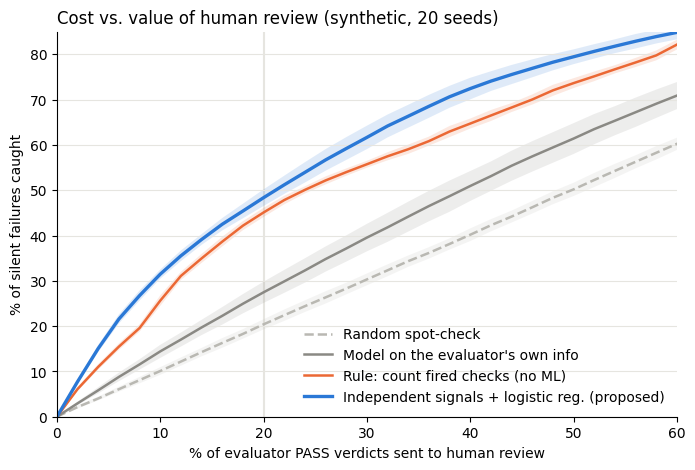

In [10]:
BLUE, ORANGE, GRAY, LIGHT = "#2a78d6", "#eb6834", "#8a8984", "#b9b8b2"
style = {"random": (LIGHT, "--"), "surface_rf": (GRAY, "-"), "rules": (ORANGE, "-"), "structural_lr": (BLUE, "-")}
fig, ax = plt.subplots(figsize=(8, 5))
for m, (col, ls) in style.items():
    a = np.array(curves[m]) * 100
    ax.fill_between(budgets * 100, a.mean(0) - a.std(0), a.mean(0) + a.std(0), color=col, alpha=.15, lw=0)
    ax.plot(budgets * 100, a.mean(0), color=col, ls=ls, lw=2.4 if m == "structural_lr" else 1.8, label=LABELS[m])
ax.axvline(20, color="#e6e5e0", zorder=0); ax.set_xlim(0, 60); ax.set_ylim(0, 85)
ax.set_xlabel("% of evaluator PASS verdicts sent to human review"); ax.set_ylabel("% of silent failures caught")
ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", color="#e6e5e0")
ax.legend(frameon=False, loc="lower right"); ax.set_title("Cost vs. value of human review (synthetic, 20 seeds)", loc="left")
plt.show()

At a 20% review budget, random review catches 20% of silent failures, and so does anything that only re-reads the evaluator's inputs (≈28%). Independent execution signals catch **about 48%**, which is **2.4× random**.

Note that the orange rule curve sits close to the blue one. I didn't expect the rule to be this close. Most of the gain comes from having the signals at all. Section 6 is where the model actually earns its keep.

## 6 · Where the model beats the rule: when review is scarce

In [11]:
t5 = res[res.budget == 0.05].groupby("method")[["catch", "precision"]].mean().loc[order] * 100
t5.columns = ["% of silent failures caught", "% of escalations that were real failures"]
t5.round(1)

,% of silent failures caught,% of escalations that were real failures
method,,
Random spot-check,5.0,24.9
Model on the evaluator's own info,7.4,36.6
Rule: count fired checks (no ML),13.4,66.4
Independent signals + logistic reg. (proposed),18.5,91.9
Independent signals + random forest,17.4,86.2
Both + random forest,17.3,85.8


At a 5% budget, **92 of every 100 escalations** from the logistic model are real failures. The rule gets 66 and random gets 25. The rule treats every fired check as equal. The model learns that a failed database read-back is much stronger evidence than a slightly low coverage reading. That matters most when reviewer time is the bottleneck.

## 7 · At a realistic failure rate
25% silent failures among PASS verdicts is far too high for a production evaluator. So here I keep the same models and subsample the silent failures down to **5%** and **2%** of PASS verdicts.

In [12]:
rows = []
for seed in range(1, N_SEEDS + 1):
    ps, scores, _ = run_one_seed(seed, methods=["random", "rules", "structural_lr"])
    sf = (ps.ground_truth_pass == 0).to_numpy(); rng = np.random.default_rng(20_000 + seed)
    ok, bad = np.where(~sf)[0], np.where(sf)[0]
    for prev in [0.05, 0.02]:
        pick = np.concatenate([ok, rng.choice(bad, int(prev / (1 - prev) * len(ok)), replace=False)])
        for m, sc in scores.items():
            for b in [0.05, 0.10, 0.20]:
                c, p = catch_and_precision(sc[pick], sf[pick], b, rng)
                rows.append({"failure rate %": prev * 100, "method": LABELS[m], "review budget %": b * 100,
                             "caught %": c * 100, "precision %": p * 100})
prev = pd.DataFrame(rows).groupby(["failure rate %", "review budget %", "method"])[["caught %", "precision %"]].mean()
prev.sort_index(ascending=[False, True, True]).round(1)

caught %  precision %
failure rate % review budget % method                                                               
5.0            5.0             Independent signals + logistic reg. (proposed)      33.1         33.0
                               Random spot-check                                    5.1          5.1
                               Rule: count fired checks (no ML)                    19.3         19.2
               10.0            Independent signals + logistic reg. (proposed)      43.3         21.6
                               Random spot-check                                   10.3          5.1
                               Rule: count fired checks (no ML)                    36.8         18.4
               20.0            Independent signals + logistic reg. (proposed)      58.1         14.5
                               Random spot-check                                   21.5          5.4
                               Rule: count fired checks (no ML)                    51.1         12.8
2.0            5.0             Independent signals + logistic reg. (proposed)      36.6         14.5
                               Random spot-check                                    5.0          2.0
                               Rule: count fired checks (no ML)                    22.8          9.1
               10.0            Independent signals + logistic reg. (proposed)      45.3          9.0
                               Random spot-check                                   10.6          2.1
                               Rule: count fired checks (no ML)                    41.2          8.2
               20.0            Independent signals + logistic reg. (proposed)      60.4          6.0
                               Random spot-check                                   21.2          2.1
                               Rule: count fired checks (no ML)                    54.8          5.4

When 5% of PASS verdicts are wrong, reviewing 10% of PASS verdicts catches about **43%** of the failures (random: 10%). About **1 in 5** escalations is a real failure (random: 1 in 20). Catch rate holds up; precision drops. Precision is what decides reviewer cost, so it's the first thing I'd measure on real traffic.

## 8 · Why was this trace flagged? Reason codes
Logistic-regression weights double as an explanation for the reviewer. Negative weight = pushes toward "suspicious".

In [13]:
canary, ps = split(42)
aud = Auditor("structural", "lr", 42).fit(canary)
print(aud.reason_codes().to_string(float_format="%.2f"))

ps = ps.assign(audit_score=aud.score(ps))
X = build_features(ps, "structural").reindex(columns=aud.columns_, fill_value=0)
contrib = X * aud.model_.coef_[0]
def explain(i, k=3):
    c = contrib.loc[i].sort_values()[:k]
    return ", ".join(f"{n} ({v:+.2f})" for n, v in c.items() if v < 0)
top = ps.nsmallest(5, "audit_score")
pd.DataFrame({"P(truly passed)": top.audit_score.map("{:.2f}".format),
              "actually failed?": (top.ground_truth_pass == 0),
              "top reasons": [explain(i) for i in top.index]})

obs_state_recon_flag               -2.73
obs_replay_ordering_flag           -1.72
bucket_partial                     -1.68
obs_rare_path_flag                 -0.96
obs_coverage_reading_missing       -0.70
obs_coverage_reading                0.14
bucket_most_done                    0.41
obs_tool_arg_audit_score_missing    0.48
bucket_all_done                     0.57
bucket_unknown                      0.71
obs_tool_arg_audit_score            0.75
obs_replay_ordering_flag_missing    0.85
obs_state_recon_flag_missing        1.06


,P(truly passed),actually failed?,top reasons
2269,0.01,True,"obs_state_recon_flag (-2.73), bucket_partial (-1.68), obs_rare_path_flag (-0.96)"
3604,0.04,True,"obs_replay_ordering_flag (-1.72), bucket_partial (-1.68), obs_rare_path_flag (-0.96)"
1328,0.05,True,"obs_state_recon_flag (-2.73), bucket_partial (-1.68), obs_replay_ordering_flag (-0.86)"
1408,0.05,True,"obs_state_recon_flag (-2.73), bucket_partial (-1.68), obs_replay_ordering_flag (-0.86)"
3913,0.05,True,"obs_state_recon_flag (-2.73), obs_replay_ordering_flag (-1.72), obs_coverage_reading_m..."


## 9 · Where it falls short: logging, not modelling
For each failure mode: the share caught at a 20% budget, against the *ceiling*, i.e. the share of that mode's failures where its check actually ran.

In [14]:
MODES = {"a": ("Edge-case regression", "obs_coverage_reading"), "b": ("State inconsistency", "obs_state_recon_flag"),
         "c": ("Wrong tool argument", "obs_tool_arg_audit_score"), "d": ("Partial completion", None),
         "e": ("Ordering violation", "obs_replay_ordering_flag")}
rows = []
for seed in range(1, N_SEEDS + 1):
    ps, scores, _ = run_one_seed(seed, methods=["structural_lr"])
    flagged = review_top(scores["structural_lr"], 0.20, np.random.default_rng(seed))
    sf = (ps.ground_truth_pass == 0).to_numpy()
    for k, (name, col) in MODES.items():
        m = sf & (ps[f"latent_mode_{k}"] == 1).to_numpy()
        observed = (ps.obs_completion_bucket != "unknown") if col is None else ps[col].notna()
        rows.append({"mode": f"{k.upper()} {name}", "caught %": flagged[m].mean() * 100,
                     "ceiling: check ran %": observed.to_numpy()[m].mean() * 100})
pd.DataFrame(rows).groupby("mode").mean().round(1)

,caught %,ceiling: check ran %
mode,,
A Edge-case regression,46.8,88.2
B State inconsistency,81.2,85.1
C Wrong tool argument,35.3,54.8
D Partial completion,58.2,94.7
E Ordering violation,38.1,34.6


- **B (state inconsistency)** is caught about 81% of the time, close to its ceiling. The database read-back check is the strongest single signal.
- **C and E** are capped by *logging coverage*: the tool-argument audit is logged on 55% of traces and the replay check runs on 35%. No model can fix that. The fix is instrumentation, and this analysis says exactly which instrumentation to prioritise. (E slightly exceeds its ceiling because failures co-occur with other modes.)
- **A and D** have high ceilings and would improve with a larger review budget.

## 10 · Could the whole result be an artefact? Three checks

In [15]:
nc, corr, ece_rows = [], [], []
for seed in range(1, N_SEEDS + 1):
    canary, ps = split(seed); y = ps.ground_truth_pass.to_numpy(); sf = y == 0
    rng = np.random.default_rng(seed)
    base = Auditor("structural", "lr", seed).fit(canary).score(ps)
    noisy = Auditor("structural", "lr", seed, include_noise_control=True).fit(canary).score(ps)
    nc.append(catch_and_precision(noisy, sf, .2, rng)[0] - catch_and_precision(base, sf, .2, rng)[0])
    corr.append(np.corrcoef(ps.evaluator_confidence, base)[0, 1])
    ece_rows.append({"logistic": ece(base, y), "random forest": ece(Auditor("structural", "rf", seed).fit(canary).score(ps), y)})
print(f"1. Negative control: adding a pure-noise feature changes catch by {np.mean(nc):+.1%} ± {1.96*np.std(nc)/np.sqrt(len(nc)):.1%}  (should be ~0)")
print(f"2. Independence: correlation between evaluator confidence and auditor score = {np.mean(corr):.2f}  (low = new information)")
print(f"3. Calibration error (ECE, lower is better): {pd.DataFrame(ece_rows).mean().round(3).to_dict()}")

1. Negative control: adding a pure-noise feature changes catch by -0.2% ± 0.2%  (should be ~0)
2. Independence: correlation between evaluator confidence and auditor score = 0.06  (low = new information)
3. Calibration error (ECE, lower is better): {'logistic': 0.042, 'random forest': 0.053}


All three look fine. Calibration matters if the probabilities ever feed a cost formula (e.g. "escalate when expected cost of a miss > cost of a review"). The logistic model is usable as-is. The forest would need recalibration first.

## 11 · Robustness and distribution shift *(synthetic-to-synthetic only)*

In [16]:
def perturb(df, noise, miss, flip, seed):
    rng = np.random.default_rng(seed + 9000); out = df.copy()
    for c in ["obs_coverage_reading", "obs_tool_arg_audit_score"]:
        out[c] = np.clip(out[c] + rng.normal(0, noise, len(out)), 0, 1)
        out.loc[rng.random(len(out)) < miss, c] = np.nan
    for c in ["obs_state_recon_flag", "obs_replay_ordering_flag"]:
        f = (rng.random(len(out)) < flip) & out[c].notna(); out.loc[f, c] = 1 - out.loc[f, c]
        out.loc[rng.random(len(out)) < miss, c] = np.nan
    f = rng.random(len(out)) < flip; out.loc[f, "obs_rare_path_flag"] = 1 - out.loc[f, "obs_rare_path_flag"]
    return out

LEVELS = [("as modeled", 0, 0, 0), ("mild extra noise", .08, .05, .03), ("moderate", .16, .12, .08), ("severe", .30, .25, .18)]
rows = []
for seed in range(1, N_SEEDS + 1):
    canary, ps = split(seed); a = Auditor("structural", "lr", seed).fit(canary); rng = np.random.default_rng(seed)
    for name, n, m, f in LEVELS:
        p = perturb(ps, n, m, f, seed)
        rows.append({"condition": name, "caught % @20%": 100 * catch_and_precision(a.score(p), p.ground_truth_pass == 0, .2, rng)[0]})
    _, shifted = split(seed + 500, complexity_lo=0.35, rare_path_base=0.30, rare_path_slope=0.30)
    rows.append({"condition": "harder task mix (shift)", "caught % @20%": 100 * catch_and_precision(a.score(shifted), shifted.ground_truth_pass == 0, .2, rng)[0]})
pd.DataFrame(rows).groupby("condition", sort=False).mean().round(1)

,caught % @20%
condition,
as modeled,48.4
mild extra noise,45.0
moderate,40.2
severe,32.9
harder task mix (shift),41.6


Performance degrades gradually, not all at once. Even the *severe* setting stays above the model that only sees the evaluator's own information (≈28%). Real distribution shift on production traffic is **untested** and can't be claimed from this.

## 12 · How many human labels does it need?

In [17]:
rows = []
for size in [100, 150, 300, 600, 1200]:
    for seed in range(1, 11):
        ps, scores, _ = run_one_seed(seed, canary_size=size, methods=["structural_lr", "combined_rf"])
        sf = (ps.ground_truth_pass == 0).to_numpy(); rng = np.random.default_rng(seed)
        for m, sc in scores.items():
            rows.append({"labelled traces": size, "method": LABELS[m], "caught % @20%": 100 * catch_and_precision(sc, sf, .2, rng)[0]})
pd.DataFrame(rows).pivot_table(index="labelled traces", columns="method", values="caught % @20%").round(1)

method,Both + random forest,Independent signals + logistic reg. (proposed)
labelled traces,,
100,34.8,41.0
150,39.3,45.5
300,46.9,49.3
600,52.2,51.8
1200,54.2,52.6


Around 150–300 labelled traces are enough for the logistic model. The bigger forest only pulls ahead past about 600 labels, so start simple.

## 13 · Where this plugs in

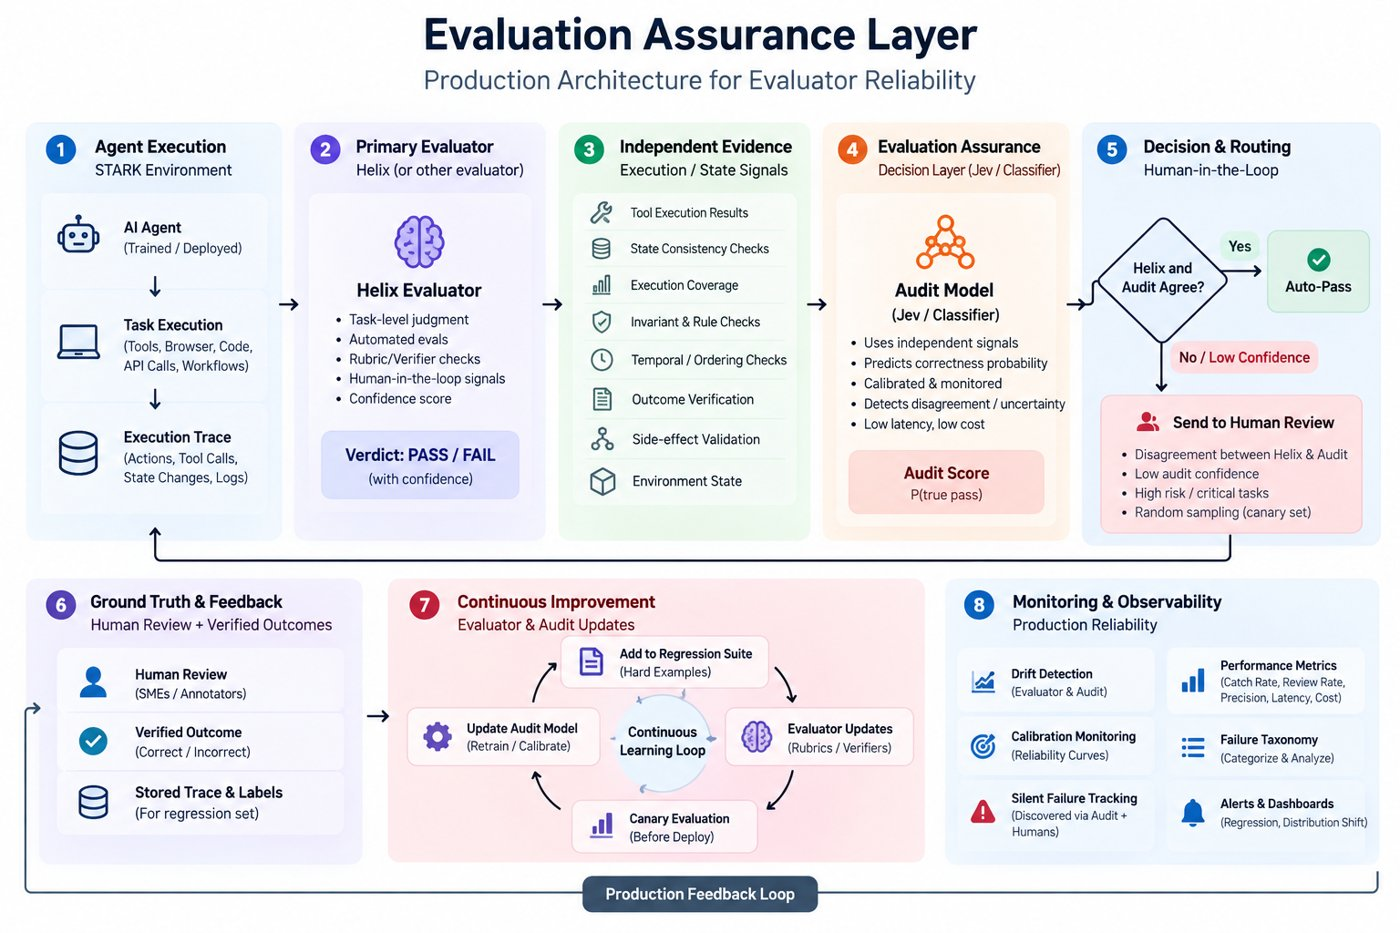

**Deployment sketch**
- **Placement:** a sidecar step right after the evaluator's verdict and before human routing. It reads the checks the environment already logs (state/SQL verification, trace checks, tool logs).
- **Cost:** about 15 weights, microseconds per trace on a CPU. It runs as a batch or streaming job, with no GPU and no external API on the critical path.
- **Output:** a suspicion score plus reason codes, feeding the existing human-review queue and filling the review budget from the top.
- **Learning loop:** reviewer labels go into the canary set, with a weekly refit (seconds) and a drift check on the score distribution.
- **Second use:** RL environments. Flag rollouts where the verifier said PASS but state checks disagree, which is a reward-hacking signature.

## 14 · How I got here: four versions, two of them wrong

| Version | What happened | Lesson |
|---|---|---|
| **V1** | Auditor used task metadata only, the same kind of information as the judge. About 4% of silent failures caught. | Another model on the same evidence adds almost nothing. |
| **V2** | AUC 0.91, 54% caught. **Invalid:** the coverage feature was built from the same equation as the label, and a two-line rule matched the model. | Always compare against the simplest possible baseline. |
| **V3** | Hard split between latent causes and noisy observed proxies, plus a leakage guard. 47% vs 28%. A single seed suggested "combined > structural"; 20 seeds showed that was noise. | Don't trust one seed. |
| **V4** *(this notebook)* | Applied the V2 lesson to V3: added random and rule baselines. The rule got close (45%), so the claim changed from "ML catches more" to "ML ranks better when review is scarce". Switched to logistic regression, trained on PASS verdicts only, and tested at realistic failure rates. | Narrower claim, but one I can defend. |

## 15 · Optional: Jev as a plug-in scorer *(not used for any result above)*

[Jev](https://typesafe.ai/blog/introducing-system-one-models-and-jev) is TypeSafe's "System One" model. It answers typed questions (yes/no, choice, score) with calibrated probabilities in roughly 70–500 ms. It adds nothing for signals that are already numbers; the logistic model handles those. It could help with evidence that **isn't** a number yet, like free-text tool outputs or error messages.

Guard-rails if it were ever used: the **official SDK only** (`typesafe-sdk`, docs.typesafe.ai, *not* third-party wrapper sites), redacted trace summaries only, never on the critical path (circuit breaker + fallback to the in-house score), `retry_after`-aware exponential backoff on 429s instead of a hard-coded rate limit, and the blend weight fit on the canary set. It's in the repo as `src/jev_adapter.py`:

```python
from typesafe_sdk import TypeSafeClient, Noul          # pip install typesafe-sdk; TYPESAFE_API_KEY
client = TypeSafeClient()
r = client.system_one(redacted_trace_summary,
        {"truly_passed": Noul(instructions="Did the agent truly complete the task?")})
p_jev = r.nouls["truly_passed"].noul                   # probability in [0, 1]
score = 0.7 * p_inhouse + 0.3 * p_jev                  # weight fit on the canary set
```

## 16 · Limitations, and the pilot that would settle it

**Limitations**
1. The five failure modes are plausible constructions, not taken from real failure logs.
2. The execution checks are simulated as noisy copies of the true failure. Their real quality is unknown, and that's the main thing a pilot measures.
3. Realistic failure rates are tested only by subsampling.
4. Robustness and shift tests are synthetic-to-synthetic.
5. It assumes labelling about 300 PASS verdicts is affordable.

**Pilot:** 200–500 anonymized traces with existing evaluator verdicts, the checks that are really logged, and trusted outcomes. Same code: swap the mock evaluator for the logged verdicts and the `obs_*` columns for the real checks.

**Ship criterion:** beat **both** random review and the rule baseline at the target budget, with non-overlapping confidence intervals. If it doesn't, don't ship it. This notebook is built to show that outcome as clearly as a positive one.